# Customer Segmentation using Clustering & PCA

**Goal:** Segment mall customers into meaningful groups using **K-Means**, **Hierarchical Clustering**, and reduce dimensions with **PCA** for visualization.

**Concepts used:** Clustering, PCA, Elbow Method, Silhouette Score, EDA

**Business value:** Helps a business target marketing campaigns to specific customer groups (e.g. high income + low spenders vs high income + high spenders).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)
np.random.seed(42)

## 1. Create / Load Dataset
We simulate a realistic **Mall Customers** dataset (Age, Annual Income, Spending Score). You can replace this with the real Kaggle 'Mall_Customers.csv' by using `pd.read_csv('Mall_Customers.csv')` instead.

In [2]:
n = 400
age = np.random.randint(18, 70, n)
income = np.random.randint(15, 140, n)  # in $1000s

# Spending score depends non-linearly on age & income to create natural clusters
spending = []
for a, inc in zip(age, income):
    if inc < 40:
        s = np.random.normal(70, 15) if a < 35 else np.random.normal(40, 15)
    elif inc < 90:
        s = np.random.normal(50, 20)
    else:
        s = np.random.normal(25, 15) if a > 45 else np.random.normal(80, 10)
    spending.append(np.clip(s, 1, 100))

df = pd.DataFrame({'Age': age, 'AnnualIncome_k': income, 'SpendingScore': np.array(spending).round(1)})
df.head()

,Age,AnnualIncome_k,SpendingScore
0,56,68,27.9
1,69,72,65.2
2,46,81,39.0
3,32,118,55.4
4,60,60,51.1


In [3]:
df.describe()

,Age,AnnualIncome_k,SpendingScore
count,400.000000,400.000000,400.000000
mean,43.987500,77.305000,52.946000
std,14.966373,36.832711,24.615569
min,18.000000,15.000000,1.000000
25%,32.000000,44.750000,33.375000
50%,45.000000,76.000000,51.650000
75%,56.000000,110.000000,73.625000
max,69.000000,139.000000,100.000000


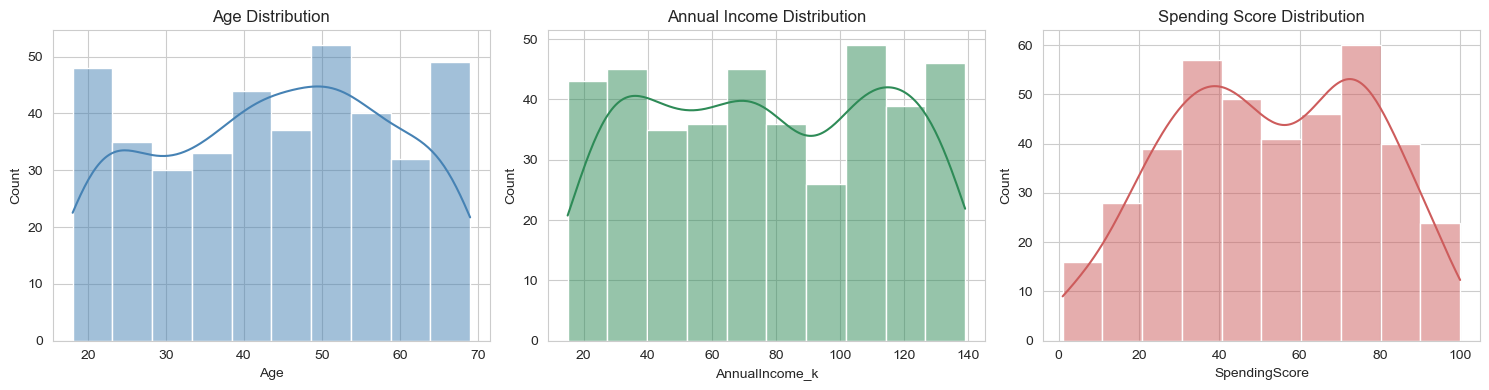

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
sns.histplot(df['AnnualIncome_k'], kde=True, ax=axes[1], color='seagreen')
sns.histplot(df['SpendingScore'], kde=True, ax=axes[2], color='indianred')
axes[0].set_title('Age Distribution')
axes[1].set_title('Annual Income Distribution')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

C:\Users\anjan\Downloads\New folder\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


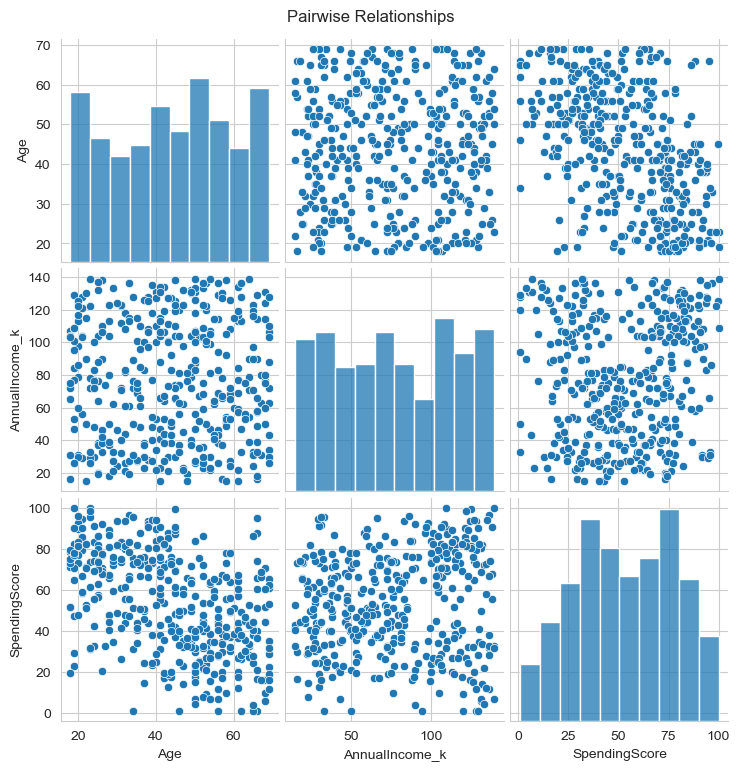

In [5]:
sns.pairplot(df)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

## 2. Feature Scaling
Clustering algorithms are distance-based, so we must standardize features.

In [6]:
features = df[['Age', 'AnnualIncome_k', 'SpendingScore']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

## 3. Elbow Method + Silhouette Score to Find Optimal K

C:\Users\anjan\Downloads\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anjan\Downloads\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anjan\Downloads\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anjan\Downloads\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMe

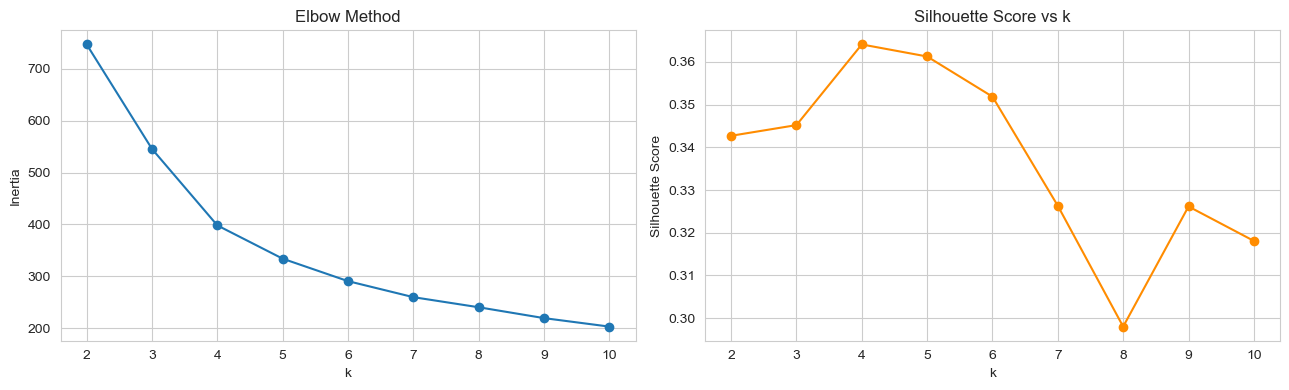

Best k by silhouette score: 4


In [7]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best k by silhouette score: {best_k}')

## 4. Fit Final K-Means Model

In [8]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)
df.groupby('Cluster')[['Age','AnnualIncome_k','SpendingScore']].mean().round(1)

C:\Users\anjan\Downloads\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Age,AnnualIncome_k,SpendingScore
Cluster,,,
0,32.5,112.6,79.6
1,54.6,49.6,44.6
2,57.2,115.3,25.9
3,29.1,49.4,59.3


## 5. Dimensionality Reduction with PCA (for visualization)

Explained variance ratio: [0.49600623 0.33181145]
Total variance captured: 0.828


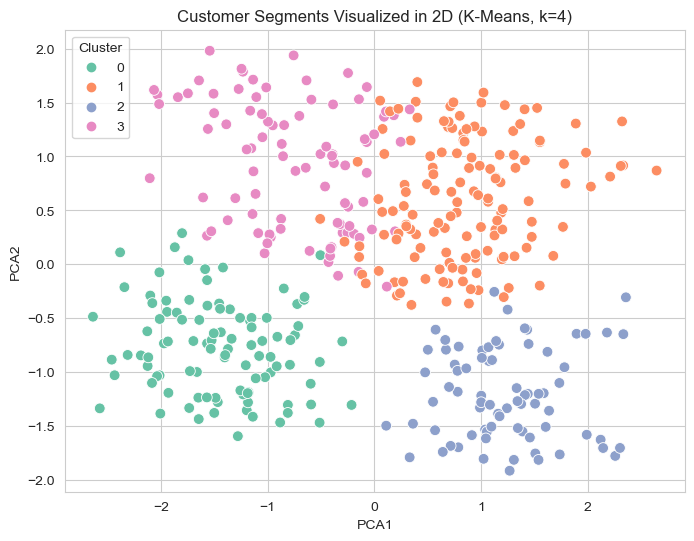

In [9]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)
df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance captured:', pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=60)
plt.title(f'Customer Segments Visualized in 2D (K-Means, k={best_k})')
plt.show()

## 6. Compare with Hierarchical Clustering (Dendrogram)

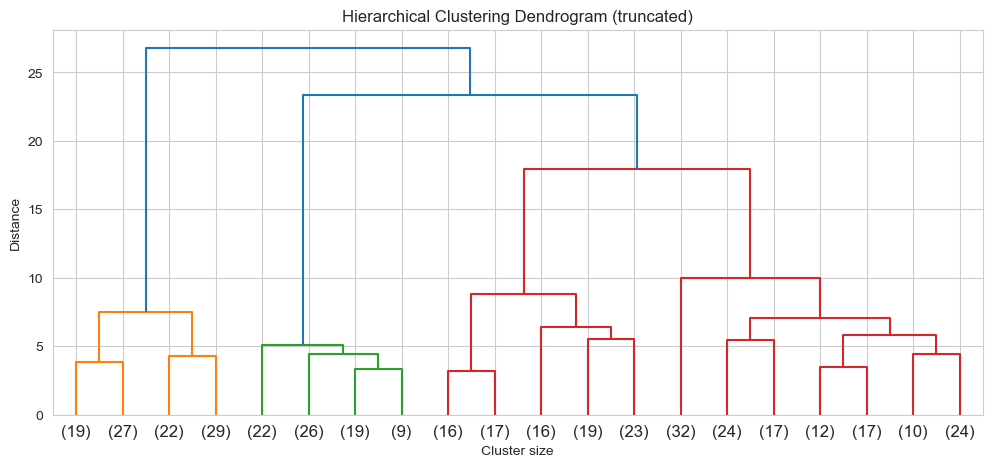

Agreement between KMeans and Hierarchical (Adjusted Rand-like check):
Cluster_Hierarchical    0   1   2   3
Cluster                              
0                       0   5   1  92
1                     136   2   0   0
2                       0   0  75   0
3                       0  84   0   5


In [10]:
linked = linkage(scaled, method='ward')
plt.figure(figsize=(12,5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

agglo = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster_Hierarchical'] = agglo.fit_predict(scaled)
print('Agreement between KMeans and Hierarchical (Adjusted Rand-like check):')
print(pd.crosstab(df['Cluster'], df['Cluster_Hierarchical']))

## 7. Cluster Profiling & Business Insight

In [11]:
profile = df.groupby('Cluster').agg(
    Count=('Cluster','size'),
    Avg_Age=('Age','mean'),
    Avg_Income_k=('AnnualIncome_k','mean'),
    Avg_Spending=('SpendingScore','mean')
).round(1)
profile

,Count,Avg_Age,Avg_Income_k,Avg_Spending
Cluster,,,,
0,98,32.5,112.6,79.6
1,138,54.6,49.6,44.6
2,75,57.2,115.3,25.9
3,89,29.1,49.4,59.3


In [12]:
for c in sorted(df['Cluster'].unique()):
    row = profile.loc[c]
    print(f"Cluster {c}: {int(row.Count)} customers | Avg Age {row.Avg_Age} | "
          f"Avg Income ${row.Avg_Income_k}k | Avg Spending Score {row.Avg_Spending}")

Cluster 0: 98 customers | Avg Age 32.5 | Avg Income $112.6k | Avg Spending Score 79.6
Cluster 1: 138 customers | Avg Age 54.6 | Avg Income $49.6k | Avg Spending Score 44.6
Cluster 2: 75 customers | Avg Age 57.2 | Avg Income $115.3k | Avg Spending Score 25.9
Cluster 3: 89 customers | Avg Age 29.1 | Avg Income $49.4k | Avg Spending Score 59.3


## 8. Conclusion

- We segmented customers into **distinct groups** using K-Means, validated the optimal number of clusters with the **Elbow Method** and **Silhouette Score**, and visualized them in 2D using **PCA**.
- **Hierarchical clustering** was used as a cross-check and largely agrees with K-Means.
- Each cluster represents a distinct marketing persona (e.g. high-income low-spenders → target with loyalty offers; young high-spenders → target with trend-driven promotions).
